# A03 – Data Wrangling: Room Occupancy Estimation
**TC5061 MLOps · Maestría en Inteligencia Artificial Aplicada (ITESM)**
**Alumno:** Erik Román Cortez · **Matrícula:** A01793714

**Objetivo.** Diagnosticar y limpiar `modified.csv`, una versión perturbada del dataset *Room Occupancy Estimation* (UCI id 864), y comparar el resultado contra `original.csv` (línea base) para medir qué tanto se recupera la distribución real.

**Estructura del notebook**
1. Configuración y carga (rutas relativas, lectura "en crudo")
2. Diagnóstico (9 pruebas sobre `modified.csv`, **sin modificarlo**)
3. Limpieza común: normalización, columna espuria, timestamps, duplicados, outliers
4. Tres estrategias de tratamiento de faltantes: A) eliminación, B) mediana/moda, C) interpolación temporal
5. EDA comparativa contra el original sin duplicados (KS, Wasserstein, Δmedia, Δstd, correlaciones, error de imputación)
6. Validación con `assert` y exportación de CSV limpios por estrategia

## 1. Configuración

Todas las rutas son **relativas** al notebook (`../data` y `../outputs`), así el proyecto se puede clonar y ejecutar en otra máquina sin editar nada. El proceso es **determinista** (no hay muestreo aleatorio), por lo que dos ejecuciones producen exactamente los mismos CSV.

In [2]:
import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.stats import ks_2samp, wasserstein_distance

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

DATA_DIR = Path("../data")
OUT_DIR = Path("../outputs")
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("pandas", pd.__version__, "| numpy", np.__version__, "| scipy", scipy.__version__)

pandas 3.0.6 | numpy 2.5.3 | scipy 1.18.1


### 1.1 Carga en crudo

`modified.csv` se lee con `dtype=str` y `keep_default_na=False`. **¿Por qué?** Si dejamos que pandas infiera tipos, convierte en silencio algunos tokens (`"null"`, `"n/a"`) a `NaN` y deja otros (`"error"`, `"?"`) como texto, y además oculta los espacios en blanco. Leer todo como texto nos deja ver el archivo **tal como viene** para poder diagnosticarlo. El original sí se lee normal porque es la referencia limpia.

In [3]:
with open(DATA_DIR / "metadata.json", encoding="utf-8") as f:
    meta = json.load(f)

orig = pd.read_csv(DATA_DIR / "original.csv")
raw = pd.read_csv(DATA_DIR / "modified.csv", dtype=str, keep_default_na=False)

ORIG_COLS = list(orig.columns)
KEY = ["Date", "Time"]                      # cada lectura de sensores tiene un timestamp único
NUM_COLS = ORIG_COLS[2:]                    # 17 columnas numéricas
DISCRETE = {"S6_PIR": [0, 1], "S7_PIR": [0, 1], "Room_Occupancy_Count": [0, 1, 2, 3]}
CONTINUOUS = [c for c in NUM_COLS if c not in DISCRETE]
INT_COLS = [c for c in NUM_COLS if pd.api.types.is_integer_dtype(orig[c])]

print("original:", orig.shape, "| modified:", raw.shape)
print("metadata rates:", meta["rates"])
raw.head()

original: (10129, 19) | modified: (10331, 20)
metadata rates: {'dup_rate': 0.02, 'nan_rate': 0.01, 'outlier_rate': 0.01, 'bad_token_rate': 0.005, 'obj_noise_rate': 0.05, 'add_mixed_type': True}


,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count,mixed_type_col
0,2017/12/22,10:49:41,24.94,345.75,24.56,25.38,121.0,34.0,53.0,40.0,0.08,0.19,0.06,0.06,390.0,0.769230769231,0.0,0.0,1.0,599
1,2017/12/22,10:50:12,24.94,24.75,24.56,25.44,121.0,33.0,53.0,40.0,0.93,0.05,0.06,0.06,390.0,0.646153846154,0.0,0.0,1.0,
2,2017/12/22,10:50:42,25.0,24.75,24.5,25.44,121.0,34.0,53.0,40.0,0.43,0.11,0.08,0.06,390.0,0.519230769231,0.0,0.0,1.0,unknown
3,2017/12/22,10:51:13,25.0,24.75,24.56,25.44,121.0,34.0,53.0,40.0,0.41,0.1,0.1,0.09,390.0,0.388461538462,0.0,0.0,1.0,584
4,2017/12/22,10:51:44,25.0,24.75,24.56,25.44,121.0,34.0,54.0,40.0,0.18,0.06,0.06,0.06,390.0,0.253846153846,0.0,0.0,1.0,bad


### 1.2 Funciones auxiliares

Se definen una sola vez para que el diagnóstico y la limpieza usen **exactamente las mismas reglas**.

- `BAD_TOKENS`: textos que representan "dato inválido" y deben tratarse como faltantes.
- `DOMAIN_RULES`: rangos físicamente plausibles por tipo de sensor (no se calculan del original, salen del contexto: temperatura de interior, luz de oficina en lux, voltaje del micrófono 0–5 V, CO₂ en ppm). Los sensores PIR son binarios y la ocupación va de 0 a 3 personas según la descripción de UCI.
- `hampel_flags`: **filtro de Hampel**, detector de outliers para series de tiempo. Compara cada lectura con la mediana de su ventana (vecinos en el tiempo) y la marca si se aleja más de *k* veces la MAD local. Es robusto porque la mediana y la MAD no se dejan arrastrar por el propio outlier. Se le pone un piso (`floor`) a la MAD para no marcar variaciones mínimas cuando la señal está plana (p. ej. luz = 0 toda la noche).

In [7]:
BAD_TOKENS = {"", "?", "error", "invalid", "nan", "n/a", "na", "null", "none"}

DOMAIN_RULES = {            # (mínimo, máximo) físicamente plausibles
    "Temp": (15, 35),       # °C, interior de un edificio
    "Light": (0, 1000),     # lux, iluminación interior
    "Sound": (0, 5),        # V, salida analógica del micrófono
    "CO2": (300, 5000),     # ppm, rango típico de sensores NDIR de interior
}
# Parámetros del filtro de Hampel por familia: (ventana, k, piso de la MAD)
HAMPEL = {
    "Temp": (7, 6, 0.25),
    "Light": (7, 6, 5),
    "Sound": (7, 10, 0.25),   # k más alto: el sonido tiene picos reales (voz) que NO son errores
    "CO2": (7, 6, 20),
    "Slope": (7, 6, 0.10),
}

def family(col):
    if col.endswith("_Slope"):
        return "Slope"
    for fam in ("Temp", "Light", "Sound", "CO2"):
        if fam in col:
            return fam
    return None

def normalize(df):
    # Quita espacios y convierte tokens inválidos a NaN (no castea tipos).
    out = df.apply(lambda s: s.str.strip())
    return out.mask(out.apply(lambda s: s.str.lower().isin(BAD_TOKENS)))

def to_numeric(df, cols):
    out = df.copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def domain_flags(s, col):
    # True donde el valor viola la regla de dominio (NaN no cuenta como violación).
    if col in DISCRETE:
        return s.notna() & ~s.isin(DISCRETE[col])
    if col.endswith("_Slope"):
        return pd.Series(False, index=s.index)   # la pendiente puede ser negativa: sólo Hampel
    lo, hi = DOMAIN_RULES[family(col)]
    return (s < lo) | (s > hi)

def hampel_flags(s, window, k, floor):
    med = s.rolling(window, center=True, min_periods=3).median()
    mad = (s - med).abs().rolling(window, center=True, min_periods=3).median() * 1.4826
    return ((s - med).abs() > k * mad.clip(lower=floor)).fillna(False)

def outlier_mask(df):
    # Combina regla de dominio + Hampel. Requiere df ordenado cronológicamente.
    mask = pd.DataFrame(False, index=df.index, columns=NUM_COLS)
    for c in NUM_COLS:
        dom = domain_flags(df[c], c)
        mask[c] = dom
        if c in CONTINUOUS:
            w, k, fl = HAMPEL[family(c)]
            mask[c] |= hampel_flags(df[c].mask(dom), w, k, fl)
    return mask

def parse_ts(df):
    return pd.to_datetime(df["Date"] + " " + df["Time"], format="%Y/%m/%d %H:%M:%S", errors="coerce")

## 2. Diagnóstico de `modified.csv` (antes de limpiar)

Nueve pruebas. Ninguna modifica `raw`: cuando una prueba necesita valores numéricos se trabaja sobre una **copia temporal**. Al final se comparan las tasas observadas contra las tasas declaradas en `metadata.json`.

### D1. Integridad del archivo (hash y forma)
Verifica que trabajamos con los archivos exactos que describe `metadata.json`. Si el hash no coincide, cualquier conclusión posterior sería sobre otro dataset.

In [8]:
def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

d1 = pd.DataFrame({
    "esperado": [meta["hash_original_csv"][:16] + "…", meta["hash_modified_csv"][:16] + "…",
                 tuple(meta["shape_original"]), tuple(meta["shape_modified"])],
    "observado": [sha256(DATA_DIR / "original.csv")[:16] + "…", sha256(DATA_DIR / "modified.csv")[:16] + "…",
                  orig.shape, raw.shape],
}, index=["hash original", "hash modified", "shape original", "shape modified"])
d1["ok"] = d1["esperado"] == d1["observado"]
d1

,esperado,observado,ok
hash original,b1233661bf4ef0bf…,b1233661bf4ef0bf…,True
hash modified,53d80813eda203f3…,53d80813eda203f3…,True
shape original,"(10129, 19)","(10129, 19)",True
shape modified,"(10331, 20)","(10331, 20)",True


### D2. Esquema: columnas y tipos
Compara las columnas contra el original y revisa qué tipo infiere pandas en una lectura normal. Si una columna numérica se infiere como texto, hay basura dentro.

In [9]:
extra = [c for c in raw.columns if c not in ORIG_COLS]
missing = [c for c in ORIG_COLS if c not in raw.columns]
print("Columnas extra:", extra, "| Columnas faltantes:", missing)

inferred = pd.read_csv(DATA_DIR / "modified.csv").dtypes
d2 = pd.DataFrame({"dtype_original": orig.dtypes.astype(str),
                   "dtype_inferido_modified": inferred.astype(str)}).reindex(raw.columns)
n_txt = sum(not pd.api.types.is_numeric_dtype(inferred[c]) for c in NUM_COLS)
print(f"Columnas numéricas del original que se infieren como texto en modified: {n_txt} de {len(NUM_COLS)}")
d2

Columnas extra: ['mixed_type_col'] | Columnas faltantes: []
Columnas numéricas del original que se infieren como texto en modified: 17 de 17


,dtype_original,dtype_inferido_modified
Date,str,str
Time,str,str
S1_Temp,float64,str
S2_Temp,float64,str
S3_Temp,float64,str
S4_Temp,float64,str
S1_Light,int64,str
S2_Light,int64,str
S3_Light,int64,str
S4_Light,int64,str


### D3–D5. Faltantes, tokens inválidos y espacios en blanco
- **D3** cuenta celdas vacías (faltante explícito).
- **D4** cuenta tokens de texto que significan "dato inválido" (`?`, `error`, `invalid`, `NAN`, `null`, `n/a`, con distintas mayúsculas).
- **D5** cuenta celdas con espacios al inicio o final (ruido en columnas de texto que impide el casteo directo a número y rompe comparaciones de igualdad, por ejemplo al buscar duplicados).

In [10]:
cols = ORIG_COLS  # la columna extra se diagnostica aparte en D6
stripped = raw[cols].apply(lambda s: s.str.strip())
empty = (stripped == "")
token = stripped.apply(lambda s: s.str.lower().isin(BAD_TOKENS - {""}))
padded = raw[cols].apply(lambda s: s.ne(s.str.strip()))

d345 = pd.DataFrame({"vacios": empty.sum(), "tokens_invalidos": token.sum(), "con_espacios": padded.sum()})
d345.loc["TOTAL"] = d345.sum()
tok_inventory = stripped[token].stack().value_counts()
print("Inventario de tokens inválidos:\n", tok_inventory.to_string())
d345

Inventario de tokens inválidos:
 ?          187
error      179
invalid    169
NULL       158
N/A        152
NAN         87
n/a          8
ERROR        8
INVALID      7
null         6


,vacios,tokens_invalidos,con_espacios
Date,90,3,499
Time,101,5,532
S1_Temp,99,58,529
S2_Temp,113,50,499
S3_Temp,100,61,543
S4_Temp,94,58,501
S1_Light,96,52,502
S2_Light,103,59,529
S3_Light,108,68,552
S4_Light,100,44,479


### D6. Columna de tipo mixto (`mixed_type_col`)
No existe en el original. Se revisa su composición y si tiene alguna relación con la variable objetivo; si no aporta señal, es candidata a eliminarse.

In [11]:
mix = raw["mixed_type_col"].str.strip()
mix_num = pd.to_numeric(mix, errors="coerce")
d6 = pd.Series({
    "numéricos": int(mix_num.notna().sum()),
    "texto (bad/unknown)": int((mix_num.isna() & (mix != "")).sum()),
    "vacíos": int((mix == "").sum()),
}, name="filas")
print(d6.to_string())
print("Valores de texto:", mix[mix_num.isna() & (mix != "")].value_counts().to_dict())
print("Rango numérico:", mix_num.min(), "–", mix_num.max())
occ_tmp = pd.to_numeric(raw["Room_Occupancy_Count"].str.strip(), errors="coerce")
ok = occ_tmp.isin([0, 1, 2, 3]) & mix_num.notna()
print(f"Correlación de Spearman con Room_Occupancy_Count: {mix_num[ok].corr(occ_tmp[ok], method='spearman'):.4f}")

numéricos              7153
texto (bad/unknown)    2124
vacíos                 1054
Valores de texto: {'bad': 1068, 'unknown': 1056}
Rango numérico: 0.0 – 999.0
Correlación de Spearman con Room_Occupancy_Count: 0.0057


### D7. Duplicados
Tres niveles, de más estricto a más útil:
1. **Exactos en crudo**: filas idénticas carácter por carácter.
2. **Exactos tras normalizar** (quitar espacios y tokens): el ruido de espacios esconde duplicados reales.
3. **Por llave de negocio `Date + Time`**: en un log de sensores cada timestamp debe aparecer una sola vez. Como las perturbaciones se aplicaron también a las copias, dos filas con el mismo timestamp pueden diferir en algún valor y aun así ser la misma lectura. El original tiene **0** timestamps repetidos, lo que confirma que la llave es válida.

In [12]:
norm_tmp = normalize(raw[ORIG_COLS])
valid_key = norm_tmp["Date"].notna() & norm_tmp["Time"].notna()
d7 = pd.Series({
    "exactos en crudo": int(raw.duplicated().sum()),
    "exactos tras normalizar (sin mixed_type_col)": int(norm_tmp.duplicated().sum()),
    "por llave Date+Time (llave válida)": int(norm_tmp[valid_key].duplicated(KEY).sum()),
    "timestamps repetidos en original": int(orig.duplicated(KEY).sum()),
    "filas extra vs original (esperado)": raw.shape[0] - orig.shape[0],
}, name="conteo")
d7

exactos en crudo                                  1
exactos tras normalizar (sin mixed_type_col)     87
por llave Date+Time (llave válida)              189
timestamps repetidos en original                  0
filas extra vs original (esperado)              202
Name: conteo, dtype: int64

### D8. Valores fuera de dominio y outliers
Se castea una copia a número y se aplican las dos reglas definidas arriba: dominio físico y Hampel (con la serie ordenada en el tiempo y sin duplicados de llave, para que los "vecinos" sean de verdad lecturas contiguas). Aquí sólo **se cuentan**; el reemplazo se hace en la sección 3.

In [13]:
tmp = to_numeric(norm_tmp, NUM_COLS)
tmp["_ts"] = parse_ts(tmp)
tmp = tmp[tmp["_ts"].notna()].drop_duplicates(KEY).sort_values("_ts")
dom = pd.DataFrame({c: domain_flags(tmp[c], c) for c in NUM_COLS})
full = outlier_mask(tmp)
d8 = pd.DataFrame({
    "min": tmp[NUM_COLS].min(), "max": tmp[NUM_COLS].max(),
    "min_original": orig[NUM_COLS].min(), "max_original": orig[NUM_COLS].max(),
    "fuera_de_dominio": dom.sum(), "dominio+hampel": full.sum(),
})
d8.round(2)

,min,max,min_original,max_original,fuera_de_dominio,dominio+hampel
S1_Temp,24.94,3084.91,24.94,26.38,109,109
S2_Temp,24.75,2546.72,24.75,29.00,105,105
S3_Temp,24.44,2413.74,24.44,26.19,103,103
S4_Temp,24.94,2553.88,24.94,26.56,90,90
S1_Light,0.00,14308.00,0.00,165.00,11,75
S2_Light,0.00,12168.00,0.00,258.00,14,72
S3_Light,0.00,26208.00,0.00,280.00,10,51
S4_Light,0.00,5041.00,0.00,74.00,15,80
S1_Sound,0.06,993.07,0.06,3.88,79,98
S2_Sound,0.04,920.06,0.04,3.44,51,85


### D9. Validez y orden de los timestamps
Un timestamp faltante o no parseable impide ubicar la lectura en la serie (y por lo tanto deduplicar por llave o interpolar). También se revisa si las filas vienen en orden cronológico.

In [14]:
ts = parse_ts(norm_tmp)
d9 = pd.Series({
    "Date o Time faltante": int((~valid_key).sum()),
    "timestamp no parseable (con ambos presentes)": int((valid_key & ts.isna()).sum()),
    "saltos hacia atrás en el tiempo": int((ts.dropna().diff().dt.total_seconds() < 0).sum()),
}, name="filas")
print(d9.to_string())
print("Últimas filas (fuera de orden → copias anexadas al final):")
print(norm_tmp[KEY].tail(4).to_string())

Date o Time faltante                            197
timestamp no parseable (con ambos presentes)      0
saltos hacia atrás en el tiempo                 102
Últimas filas (fuera de orden → copias anexadas al final):
             Date      Time
10327  2017/12/23  18:44:53
10328  2017/12/26  08:58:47
10329  2018/01/11  06:59:09
10330  2018/01/10  17:43:09


### Resumen del diagnóstico vs `metadata.json`
Se traduce cada hallazgo a una tasa comparable con lo declarado. Los valores coinciden de cerca, lo que indica que el diagnóstico capturó las perturbaciones inyectadas. Nota: el sustituto de faltantes de metadata (`nan_rate`) se observa como celdas vacías; los tokens `NAN` en texto se cuentan como tokens inválidos.

In [15]:
n_cells = raw.shape[0] * len(ORIG_COLS)
summary = pd.DataFrame({
    "declarado": [meta["rates"]["dup_rate"], meta["rates"]["nan_rate"], meta["rates"]["outlier_rate"],
                  meta["rates"]["bad_token_rate"], meta["rates"]["obj_noise_rate"], "sí"],
    "observado": [round(d7["filas extra vs original (esperado)"] / orig.shape[0], 4),
                  round(empty.values.sum() / n_cells, 4),
                  round(full.values.sum() / (len(tmp) * len(NUM_COLS)), 4),
                  round(token.values.sum() / n_cells, 4),
                  round(padded.values.sum() / n_cells, 4),
                  f"sí ({extra})"],
}, index=["duplicados (filas)", "faltantes (celdas)", "outliers (celdas num.)",
          "tokens inválidos (celdas)", "ruido de espacios (celdas)", "columna de tipo mixto"])
summary.to_csv(OUT_DIR / "diagnostico_resumen.csv")
summary

,declarado,observado
duplicados (filas),0.02,0.0199
faltantes (celdas),0.01,0.0094
outliers (celdas num.),0.01,0.0081
tokens inválidos (celdas),0.005,0.0049
ruido de espacios (celdas),0.05,0.0498
columna de tipo mixto,sí,sí (['mixed_type_col'])


## 3. Limpieza común (aplica a todas las estrategias)

| Paso | Acción | Justificación |
|---|---|---|
| L1 | `strip()` + tokens inválidos → `NaN` | Un token como `"error"` no es un valor; es un faltante disfrazado. |
| L2 | Eliminar `mixed_type_col` | No está en el esquema original, 30 % es texto basura y no correlaciona con la ocupación (D6). |
| L3 | Castear a numérico | Ya sin ruido, todas las columnas de sensores deben ser numéricas. |
| L4 | Eliminar duplicados exactos | Requisito de la rúbrica; primera pasada barata. |
| L5 | Eliminar filas sin timestamp válido | Sin `Date+Time` la lectura no se puede ubicar en la serie, ni deduplicar por llave, ni interpolar. |
| L6 | Eliminar duplicados por llave `Date+Time` (se conserva la primera aparición) | Atrapa los duplicados que el ruido hizo "distintos" (D7). |
| L7 | Ordenar cronológicamente | Las copias venían anexadas al final; Hampel e interpolación necesitan vecinos reales. |
| L8 | Outliers (dominio + Hampel) → `NaN` | Un outlier inyectado es un valor falso; se trata como faltante para que cada estrategia decida qué hacer con él. |

In [16]:
log = {"inicio": len(raw)}

df = normalize(raw)                                    # L1
df = df.drop(columns=["mixed_type_col"])               # L2
df = to_numeric(df, NUM_COLS)                          # L3

df = df.drop_duplicates()                              # L4
log["L4 duplicados exactos"] = len(df)

df["_ts"] = parse_ts(df)                               # L5
df = df[df["_ts"].notna()]
log["L5 sin timestamp válido"] = len(df)

df = df.drop_duplicates(subset=KEY, keep="first")      # L6
log["L6 duplicados por llave"] = len(df)

df = df.sort_values("_ts").reset_index(drop=True)      # L7

out_mask = outlier_mask(df)                            # L8
nan_before = int(df[NUM_COLS].isna().sum().sum())
df[NUM_COLS] = df[NUM_COLS].mask(out_mask)
log["L8 outliers → NaN (celdas)"] = int(out_mask.values.sum())

base = df  # punto de partida común para las 3 estrategias
steps = pd.Series(log, name="filas / celdas")
print(steps.to_string())
print(f"\nNaN en columnas numéricas: {nan_before} (faltantes+tokens) + {int(out_mask.values.sum())} (outliers) "
      f"= {int(base[NUM_COLS].isna().sum().sum())}")
print(f"Filas con al menos un NaN: {int(base[NUM_COLS].isna().any(axis=1).sum())} de {len(base)}")

inicio                        10331
L4 duplicados exactos         10244
L5 sin timestamp válido       10047
L6 duplicados por llave        9945
L8 outliers → NaN (celdas)     1361

NaN en columnas numéricas: 2519 (faltantes+tokens) + 1361 (outliers) = 3880
Filas con al menos un NaN: 3194 de 9945


## 4. Estrategias para los faltantes

Se comparan tres enfoques, de más simple a más informado por el dominio:

- **A) Eliminación (listwise deletion).** Se descarta toda fila con algún `NaN`. Ventaja: no inventa datos. Desventaja: pierde muchas filas porque basta un faltante en cualquiera de 17 columnas, y si los faltantes no fueran completamente aleatorios (MCAR) introduciría sesgo.
- **B) Mediana / moda.** Continuas → mediana de la columna; discretas (PIR, ocupación) → moda. Ventaja: conserva todas las filas y es robusta a outliers residuales. Desventaja: ignora el tiempo y el contexto, concentra valores en un solo punto (encoge la varianza) y rompe correlaciones: una sala ocupada con luz encendida puede recibir luz = 0.
- **C) Interpolación temporal (estrategia propuesta).** Continuas → interpolación lineal en el tiempo (`method="time"`); discretas → último estado conocido (`ffill`, luego `bfill` en los bordes). Ventaja: los sensores muestrean cada ~30 s y la señal es muy autocorrelacionada, así que el mejor estimador de un hueco son sus vecinos. Usar `ffill` en las discretas respeta que un estado (ocupación, movimiento) persiste y evita valores fraccionarios como 1.5 personas.

En B y C las columnas que en el original son enteras se redondean y se castean a `int` para respetar el esquema.

In [17]:
def finalize(d):
    # Deja el mismo esquema y tipos que el original.
    d = d.copy()
    for c in INT_COLS:
        d[c] = d[c].round().astype("int64")
    return d[ORIG_COLS + ["_ts"]].reset_index(drop=True)

# A) Eliminación
clean_A = finalize(base.dropna(subset=NUM_COLS))

# B) Mediana / moda (estadísticos calculados sobre los datos ya sin outliers)
fill_B = {c: base[c].median() for c in CONTINUOUS}
fill_B.update({c: base[c].mode().iloc[0] for c in DISCRETE})
clean_B = finalize(base.fillna(value=fill_B))

# C) Interpolación temporal
tmpC = base.set_index("_ts", drop=False)
tmpC[CONTINUOUS] = tmpC[CONTINUOUS].interpolate(method="time", limit_direction="both")
tmpC[list(DISCRETE)] = tmpC[list(DISCRETE)].ffill().bfill()
clean_C = finalize(tmpC)

STRATS = {"A_eliminacion": clean_A, "B_mediana": clean_B, "C_interpolacion": clean_C}
pd.DataFrame({k: [len(v), f"{len(v) / len(orig):.1%}"] for k, v in STRATS.items()},
             index=["filas", "% del original"])

,A_eliminacion,B_mediana,C_interpolacion
filas,6751,9945,9945
% del original,66.7%,98.2%,98.2%


## 5. EDA comparativa contra el original

La referencia es `original.csv` **sin duplicados** (se aplica `drop_duplicates()` aunque no tenga, para que la comparación sea la que pide la rúbrica).

**Métricas por columna**
- **KS (Kolmogorov–Smirnov):** máxima distancia entre las dos funciones de distribución acumulada. 0 = idénticas. Se reporta el estadístico; el p-value con ~10 mil filas detecta diferencias minúsculas y en columnas con muchos empates (luz = 0, PIR) es conservador, así que el estadístico es más informativo.
- **Wasserstein normalizada:** "cuánta masa hay que mover y qué tan lejos" para convertir una distribución en la otra, dividida entre la desviación estándar original para comparar columnas de distintas unidades. A diferencia de KS, sí castiga la magnitud del desplazamiento.
- **Δmedia % y Δstd %:** cambio relativo en ubicación y dispersión. Δstd negativo indica que la imputación encogió la varianza.

In [18]:
ref = orig.drop_duplicates().reset_index(drop=True)

def compare(clean, ref):
    rows = []
    for c in NUM_COLS:
        a, b = ref[c].astype(float), clean[c].astype(float)
        ks = ks_2samp(a, b)
        rows.append({
            "col": c,
            "KS": ks.statistic,
            "KS_pvalue": ks.pvalue,
            "Wass_norm": wasserstein_distance(a, b) / a.std(),
            "dMean_%": 100 * (b.mean() - a.mean()) / abs(a.mean()) if a.mean() != 0 else np.nan,
            "dStd_%": 100 * (b.std() - a.std()) / a.std(),
        })
    return pd.DataFrame(rows).set_index("col")

metrics = {k: compare(v, ref) for k, v in STRATS.items()}
metrics_all = pd.concat(metrics, axis=1)
metrics_all.to_csv(OUT_DIR / "metricas_por_columna.csv")

resumen = pd.DataFrame({
    k: {"KS promedio": m["KS"].mean(), "KS máximo": m["KS"].max(),
        "Wass_norm promedio": m["Wass_norm"].mean(),
        "|dStd_%| promedio": m["dStd_%"].abs().mean(),
        "columnas con KS p<0.05": int((m["KS_pvalue"] < 0.05).sum())}
    for k, m in metrics.items()
}).round(4)
resumen.to_csv(OUT_DIR / "metricas_resumen.csv")
resumen

,A_eliminacion,B_mediana,C_interpolacion
KS promedio,0.0075,0.0093,0.0020
KS máximo,0.0136,0.0139,0.0050
Wass_norm promedio,0.0121,0.0124,0.0039
|dStd_%| promedio,1.6064,1.7674,1.0385
columnas con KS p<0.05,0.0000,0.0000,0.0000


In [19]:
pd.concat({k: m[["KS", "Wass_norm", "dStd_%"]] for k, m in metrics.items()}, axis=1).round(3)

A_eliminacion                  B_mediana                  C_interpolacion                 
                                KS Wass_norm dStd_%        KS Wass_norm dStd_%              KS Wass_norm dStd_%
col                                                                                                            
S1_Temp                      0.009     0.014 -0.644     0.013     0.019 -1.190           0.002     0.001 -0.021
S2_Temp                      0.010     0.015 -1.842     0.014     0.017 -1.561           0.002     0.002 -0.321
S3_Temp                      0.009     0.013 -0.149     0.012     0.020 -1.098           0.002     0.002  0.001
S4_Temp                      0.009     0.018 -0.317     0.012     0.018 -1.026           0.002     0.003 -0.046
S1_Light                     0.012     0.016 -1.387     0.011     0.010 -0.745           0.001     0.001  0.002
S2_Light                     0.012     0.013 -1.675     0.011     0.008 -0.786           0.001     0.001 -0.069
S3_Light                     0.013     0.018 -1.203     0.011     0.013 -0.714           0.001     0.001  0.155
S4_Light                     0.014     0.024 -1.199     0.011     0.019 -0.878           0.001     0.001  0.026
S1_Sound                     0.005     0.006 -0.432     0.012     0.005 -1.920           0.005     0.006 -1.570
S2_Sound                     0.004     0.012 -7.785     0.006     0.007 -3.497           0.004     0.010 -2.547
S3_Sound                     0.005     0.008 -2.752     0.008     0.013 -4.884           0.004     0.007 -3.338
S4_Sound                     0.004     0.013  4.084     0.009     0.016  7.160           0.005     0.019  8.123
S5_CO2                       0.007     0.006 -0.191     0.012     0.015 -1.130           0.001     0.001 -0.124
S5_CO2_Slope                 0.008     0.011  1.193     0.009     0.012 -1.121           0.001     0.002 -0.019
S6_PIR                       0.003     0.010 -1.382     0.001     0.004 -0.576           0.001     0.005  0.679
S7_PIR                       0.000     0.001 -0.185     0.001     0.005 -0.834           0.001     0.003  0.440
Room_Occupancy_Count         0.005     0.010 -0.889     0.004     0.010 -0.927           0.001     0.002  0.173

### 5.1 Distribuciones de variables representativas
Una variable por familia de sensor. Se busca que la curva limpia se sobreponga a la del original.

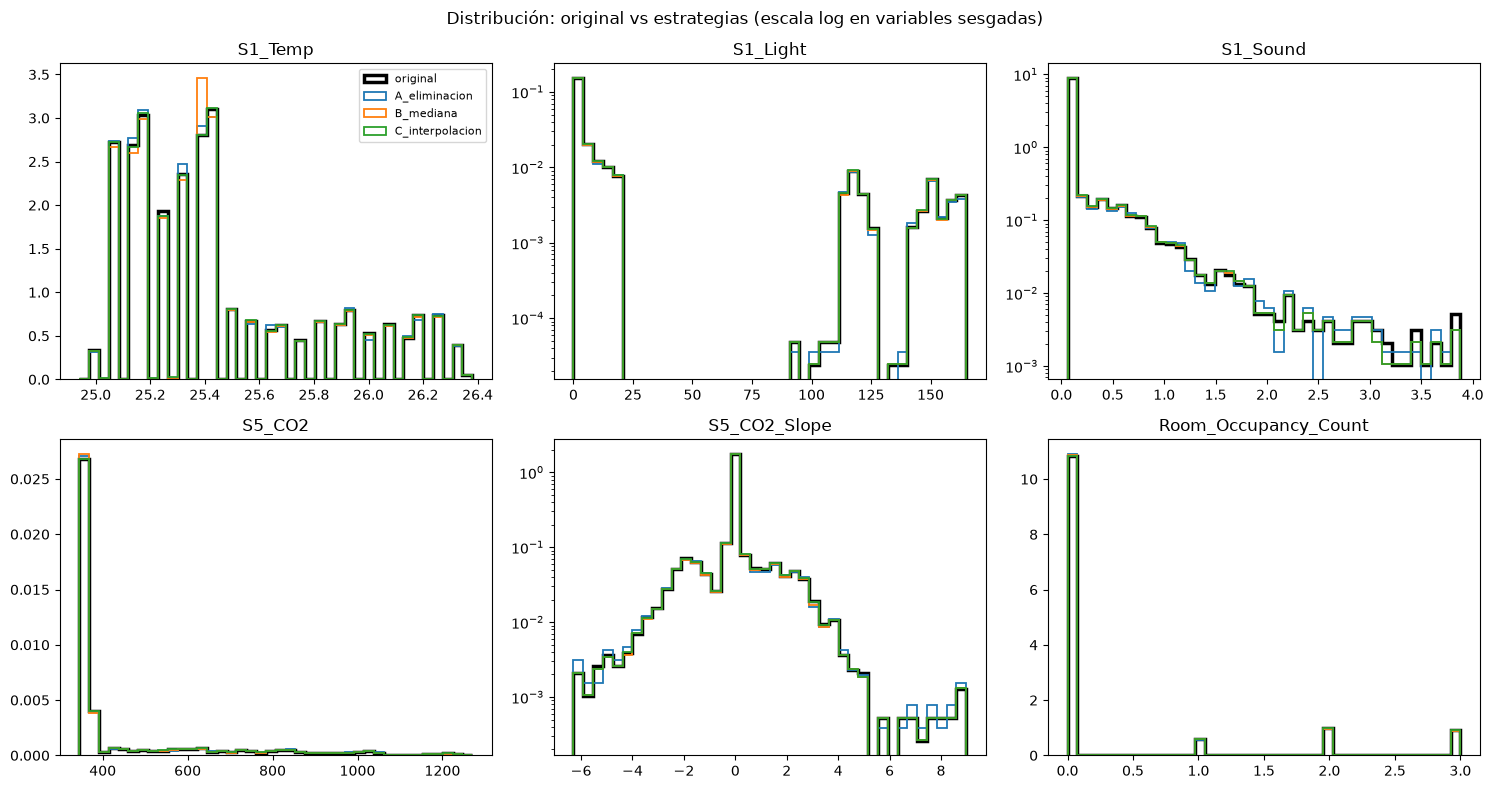

In [20]:
show = ["S1_Temp", "S1_Light", "S1_Sound", "S5_CO2", "S5_CO2_Slope", "Room_Occupancy_Count"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), show):
    bins = np.histogram_bin_edges(ref[c], bins=40)
    ax.hist(ref[c], bins=bins, density=True, histtype="step", lw=2.5, color="black", label="original")
    for (k, d), col in zip(STRATS.items(), ["tab:blue", "tab:orange", "tab:green"]):
        ax.hist(d[c], bins=bins, density=True, histtype="step", lw=1.3, color=col, label=k)
    ax.set_title(c)
    if c in ("S1_Light", "S1_Sound", "S5_CO2_Slope"):
        ax.set_yscale("log")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Distribución: original vs estrategias (escala log en variables sesgadas)")
fig.tight_layout()
fig.savefig(FIG_DIR / "distribuciones.png", dpi=150)
plt.show()

### 5.2 Balance de la variable objetivo
Si la limpieza cambia la proporción de clases, un modelo entrenado después aprendería una realidad distinta.

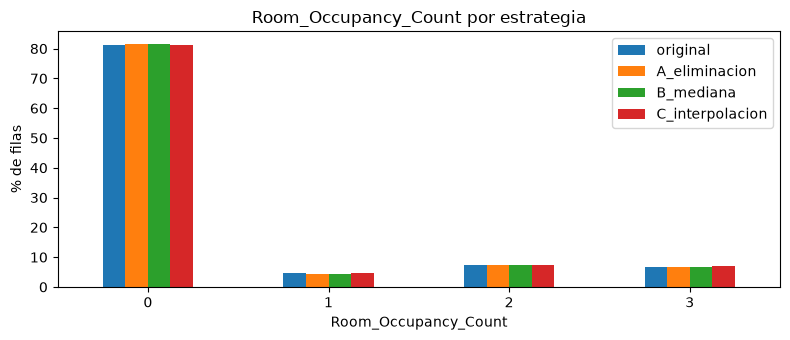

,original,A_eliminacion,B_mediana,C_interpolacion
Room_Occupancy_Count,,,,
0,81.23,81.72,81.68,81.18
1,4.53,4.31,4.39,4.56
2,7.38,7.29,7.24,7.37
3,6.85,6.68,6.69,6.90


In [21]:
occ = pd.DataFrame({"original": ref["Room_Occupancy_Count"].value_counts(normalize=True)})
for k, d in STRATS.items():
    occ[k] = d["Room_Occupancy_Count"].value_counts(normalize=True)
occ = (occ * 100).round(2).sort_index()
occ.to_csv(OUT_DIR / "balance_clases.csv")
occ.plot.bar(figsize=(8, 3.5), rot=0, ylabel="% de filas", title="Room_Occupancy_Count por estrategia")
plt.tight_layout(); plt.savefig(FIG_DIR / "balance_clases.png", dpi=150); plt.show()
occ

### 5.3 Estructura de correlación
KS y Wasserstein son univariados. Para un modelo de ocupación importan las **relaciones** entre sensores (luz, CO₂ y PIR se mueven juntos cuando hay gente). Se mide la diferencia absoluta entre la matriz de correlación limpia y la original: el **promedio** (qué tanto cambió la estructura en general) y el **máximo** (el peor par de variables).

                media |Δcorr| max |Δcorr|             peor par
A_eliminacion        0.009793    0.063029  S2_Sound × S4_Sound
B_mediana            0.020868    0.109572  S2_Sound × S4_Sound
C_interpolacion      0.008126    0.090552  S2_Sound × S4_Sound


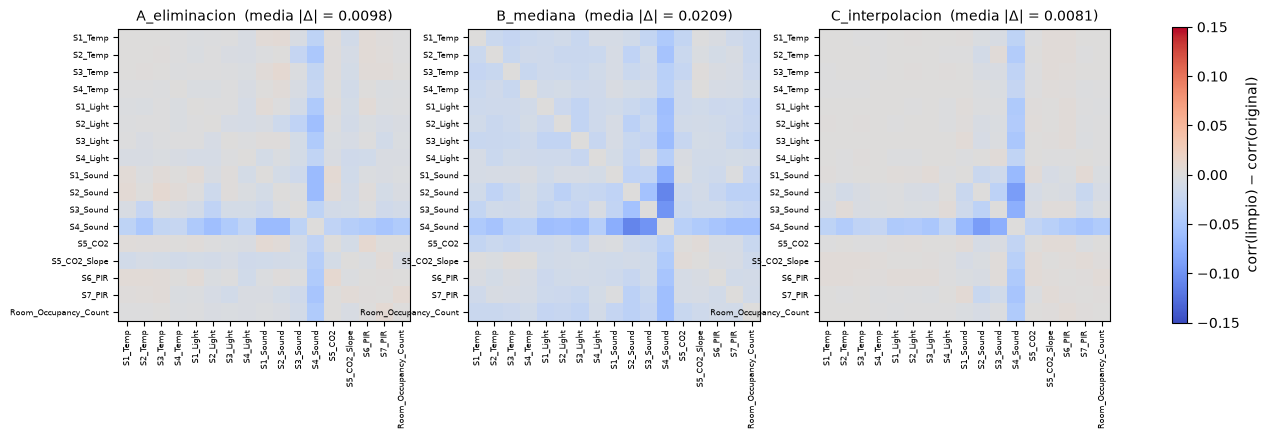

In [22]:
corr_ref = ref[NUM_COLS].corr()
upper = np.triu(np.ones((len(NUM_COLS), len(NUM_COLS)), dtype=bool), k=1)
corr_rows = {}
for k, d in STRATS.items():
    delta = (d[NUM_COLS].corr() - corr_ref).abs().where(upper).stack()
    corr_rows[k] = {"media |Δcorr|": delta.mean(), "max |Δcorr|": delta.max(),
                    "peor par": " × ".join(delta.idxmax())}
corr_tbl = pd.DataFrame(corr_rows).T
corr_tbl.to_csv(OUT_DIR / "delta_correlacion.csv")
corr_diff = corr_tbl["max |Δcorr|"].astype(float)
print(corr_tbl.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (k, d) in zip(axes, STRATS.items()):
    im = ax.imshow((d[NUM_COLS].corr() - corr_ref).values, cmap="coolwarm", vmin=-0.15, vmax=0.15)
    ax.set_title(f"{k}  (media |Δ| = {corr_tbl.loc[k, 'media |Δcorr|']:.4f})", fontsize=10)
    ax.set_xticks(range(len(NUM_COLS))); ax.set_xticklabels(NUM_COLS, rotation=90, fontsize=6)
    ax.set_yticks(range(len(NUM_COLS))); ax.set_yticklabels(NUM_COLS, fontsize=6)
fig.colorbar(im, ax=axes, shrink=0.8, label="corr(limpio) − corr(original)")
plt.savefig(FIG_DIR / "delta_correlacion.png", dpi=150, bbox_inches="tight"); plt.show()

### 5.4 Precisión de la imputación (validación a posteriori)
Como existe el original, se puede medir qué tan cerca quedó cada valor imputado del valor real. Se unen las tablas por la llave `Date+Time` y sólo se evalúan las celdas que eran `NaN` en `base` (faltantes, tokens u outliers). Esta validación **no** se usó para elegir nada: es una auditoría final.
- Continuas: error absoluto medio normalizado por la desviación estándar original (MAE/σ).
- Discretas: exactitud (% de aciertos).

También se audita el detector de outliers: de las celdas marcadas en L8, cuántas eran realmente distintas del original (precisión) y cuántas celdas alteradas de la parte numérica no se detectaron.

In [23]:
nan_cells = base.set_index(KEY)[NUM_COLS].isna()
ref_k = ref.set_index(KEY)

rows = []
for k, d in {"B_mediana": clean_B, "C_interpolacion": clean_C}.items():
    dk = d.set_index(KEY)
    for c in NUM_COLS:
        idx = nan_cells.index[nan_cells[c]].intersection(ref_k.index)
        est, true = dk.loc[idx, c].astype(float), ref_k.loc[idx, c].astype(float)
        if c in DISCRETE:
            rows.append({"estrategia": k, "col": c, "n": len(idx), "métrica": "exactitud %",
                         "valor": 100 * (est == true).mean()})
        else:
            rows.append({"estrategia": k, "col": c, "n": len(idx), "métrica": "MAE/σ",
                         "valor": (est - true).abs().mean() / ref[c].std()})
imp = pd.DataFrame(rows)
imp.to_csv(OUT_DIR / "error_imputacion.csv", index=False)
imp_summary = imp.groupby(["estrategia", "métrica"])["valor"].mean().unstack().round(3)
print(imp_summary.to_string(), "\n")

# Auditoría del detector de outliers
b_num = base.set_index(KEY)
pre = to_numeric(normalize(raw[ORIG_COLS]), NUM_COLS)
pre["_ts"] = parse_ts(pre)
pre = pre[pre["_ts"].notna()].drop_duplicates(KEY).set_index(KEY)
common = pre.index.intersection(ref_k.index).intersection(b_num.index)
altered = pre.loc[common, NUM_COLS].notna() & ~np.isclose(pre.loc[common, NUM_COLS].astype(float),
                                                         ref_k.loc[common, NUM_COLS].astype(float))
flagged = out_mask.set_index(base.set_index(KEY).index).loc[common]
tp = int((flagged & altered).values.sum()); fp = int((flagged & ~altered).values.sum())
fn = int((~flagged & altered).values.sum())
print(f"Detector de outliers → TP={tp}, FP={fp}, FN={fn} | precisión={tp/(tp+fp):.3f}, recall={tp/(tp+fn):.3f}")

métrica          MAE/σ  exactitud %
estrategia                         
B_mediana        0.625       85.708
C_interpolacion  0.163       94.089 

Detector de outliers → TP=1332, FP=29, FN=60 | precisión=0.979, recall=0.957


## 6. Validación con `assert` y exportación

Los `assert` funcionan como un **contrato de calidad** de los datos limpios: si una ejecución futura (otra versión del archivo, otro cambio en el código) rompe alguna regla, el notebook se detiene en lugar de exportar datos malos. Es la misma idea que un *data validation step* en un pipeline de MLOps.

In [24]:
for name, d in STRATS.items():
    # Esquema
    assert list(d[ORIG_COLS].columns) == ORIG_COLS, f"{name}: columnas distintas al original"
    assert all(pd.api.types.is_numeric_dtype(d[c]) for c in NUM_COLS), f"{name}: hay columnas no numéricas"
    assert all(pd.api.types.is_integer_dtype(d[c]) for c in INT_COLS), f"{name}: enteros mal tipados"
    # Completitud y unicidad
    assert d[ORIG_COLS].isna().sum().sum() == 0, f"{name}: quedan NaN"
    assert not d[ORIG_COLS].duplicated().any(), f"{name}: quedan duplicados exactos"
    assert not d.duplicated(KEY).any(), f"{name}: quedan timestamps repetidos"
    assert d["_ts"].is_monotonic_increasing, f"{name}: no está en orden cronológico"
    # Dominio
    for c, allowed in DISCRETE.items():
        assert d[c].isin(allowed).all(), f"{name}: {c} fuera de {allowed}"
    for c in CONTINUOUS:
        if not c.endswith("_Slope"):
            lo, hi = DOMAIN_RULES[family(c)]
            assert d[c].between(lo, hi).all(), f"{name}: {c} fuera de [{lo}, {hi}]"
    # Ningún token inválido sobrevivió como texto
    assert not d[["Date", "Time"]].apply(lambda s: s.str.lower().isin(BAD_TOKENS)).any().any()

# Contratos de fidelidad estadística para las estrategias que conservan filas
for name in ("B_mediana", "C_interpolacion"):
    assert len(STRATS[name]) >= 0.95 * len(ref), f"{name}: perdió más del 5 % de filas"
m_C = metrics["C_interpolacion"]
assert m_C["KS"].max() < 0.05, "C: alguna columna se alejó del original (KS ≥ 0.05)"
assert m_C["Wass_norm"].max() < 0.05, "C: alguna columna se desplazó (Wasserstein/σ ≥ 0.05)"
assert corr_tbl.loc["C_interpolacion", "media |Δcorr|"] < 0.01, "C: la estructura de correlación cambió"
assert corr_diff["C_interpolacion"] < 0.10, "C: algún par de variables cambió su correlación ≥ 0.10"
# C debe ser la mejor estrategia en las métricas globales
assert metrics["C_interpolacion"]["KS"].mean() == min(m["KS"].mean() for m in metrics.values())
assert corr_tbl["media |Δcorr|"].astype(float).idxmin() == "C_interpolacion"
print("✔ Todos los asserts pasaron")

✔ Todos los asserts pasaron


In [25]:
for name, d in STRATS.items():
    path = OUT_DIR / f"modified_clean_{name}.csv"
    d[ORIG_COLS].to_csv(path, index=False, float_format="%.12g")  # formato fijo: CSV idéntico entre versiones
    # Re-lectura: el CSV exportado debe conservar forma y no tener NaN
    back = pd.read_csv(path)
    assert back.shape == d[ORIG_COLS].shape and back.isna().sum().sum() == 0
    print(f"{path}  ->  {back.shape}")

../outputs/modified_clean_A_eliminacion.csv  ->  (6751, 19)
../outputs/modified_clean_B_mediana.csv  ->  (9945, 19)
../outputs/modified_clean_C_interpolacion.csv  ->  (9945, 19)


## 7. Conclusiones

1. **Diagnóstico.** `modified.csv` tiene seis tipos de perturbación (duplicados, faltantes, outliers, tokens inválidos, espacios y una columna de tipo mixto), con tasas observadas muy cercanas a las de `metadata.json`. Todas las columnas numéricas se leen como texto por los tokens y los espacios.
2. **Duplicados.** Los duplicados exactos casi no existen porque las copias también fueron perturbadas; la deduplicación efectiva fue por la llave de negocio `Date+Time`.
3. **Outliers.** Reglas de dominio + filtro de Hampel: precisión ≈ 0.98 y recall ≈ 0.96 en la auditoría contra el original. Los errores se concentran en los sensores de **sonido**: un valor inyectado que cae en el rango de la voz (0.5–3 V) no se distingue de un pico real, y algunos picos reales se marcan como outliers. Es el límite de detectar sin ver la etiqueta.
4. **Estrategias.** La eliminación (A) pierde un tercio de las filas (6,751 de 10,129). La mediana (B) conserva filas pero tiene la peor fidelidad en KS, Wasserstein y correlaciones, y sus imputaciones se alejan más del valor real. La interpolación temporal (C) tiene el menor KS, la menor Wasserstein, el menor cambio promedio de correlaciones, ~4× menos error de imputación que B y conserva el 98 % de las filas. El peor par de correlación de C (S2_Sound × S4_Sound) refleja la limitación del punto 3, no de la interpolación. **Se recomienda C** para entrenar modelos de ocupación.